Kütüphaneler başarıyla yüklendi.

--- Veri Setinin İlk 5 Satırı ---
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

--- Veri Seti Bilgileri (Sütunlar ve Veri Tipleri) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 

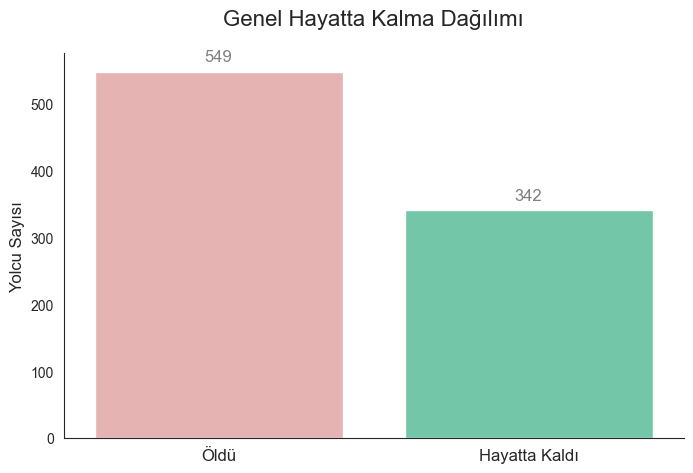

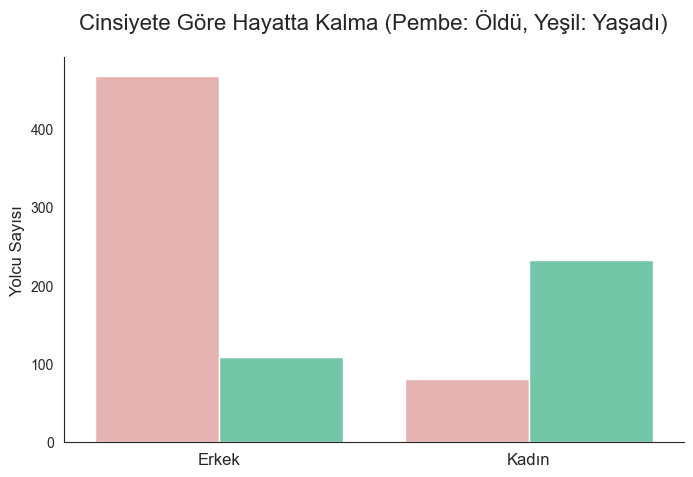

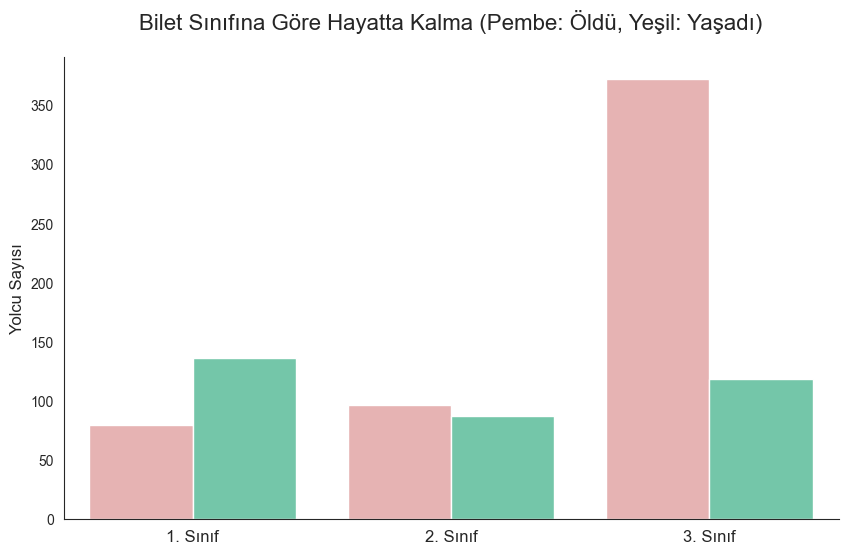

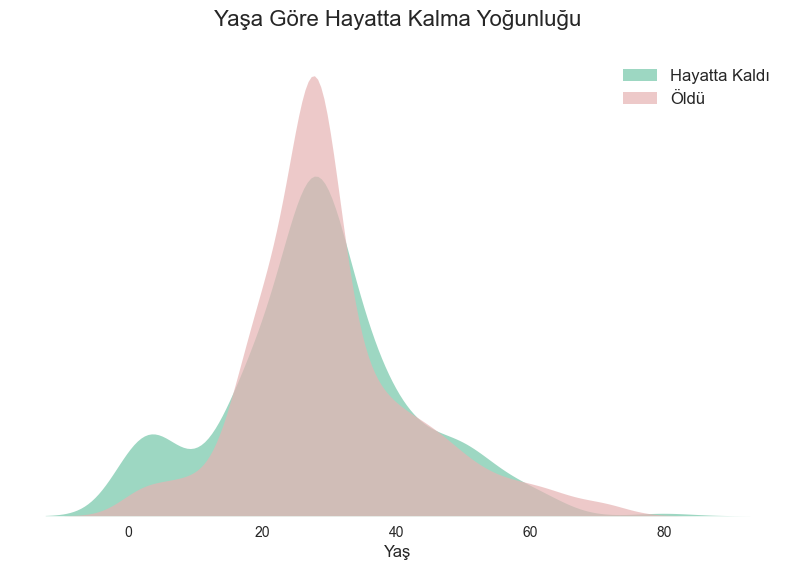


--- Model İçin Hazırlanmış Veri Seti (İlk 5 Satır) ---
   survived  pclass  sex   age     fare  embarked_Q  embarked_S  family_size
0         0       3    0  22.0   7.2500       False        True            2
1         1       1    1  38.0  71.2833       False       False            2
2         1       3    1  26.0   7.9250       False        True            1
3         1       1    1  35.0  53.1000       False        True            2
4         0       3    0  35.0   8.0500       False        True            1

Eğitim seti boyutu: 712 yolcu
Test seti boyutu: 179 yolcu

--- Lojistik Regresyon Modeli Başarıyla Eğitildi ---

--- Model 1: Lojistik Regresyon Sonuçları ---
Doğruluk (Accuracy) Skoru: 0.7989 (Yani yaklaşık %79.89)

Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.81      0.88      0.84       110
           1       0.78      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.79 

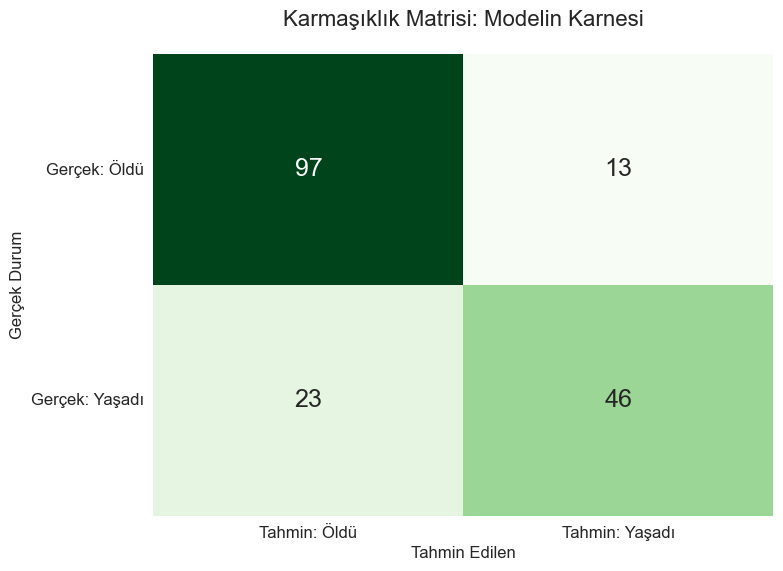


--- Model 2: Random Forest Doğruluk Skoru ---
Doğruluk (Accuracy) Skoru: 0.8156 (Yani yaklaşık %81.56)

--- Modelın Kararını Etkileyen En Önemli Özellikler ---
fare           0.286711
sex            0.261910
age            0.254827
pclass         0.086806
family_size    0.077284
embarked_S     0.022998
embarked_Q     0.009465
dtype: float64


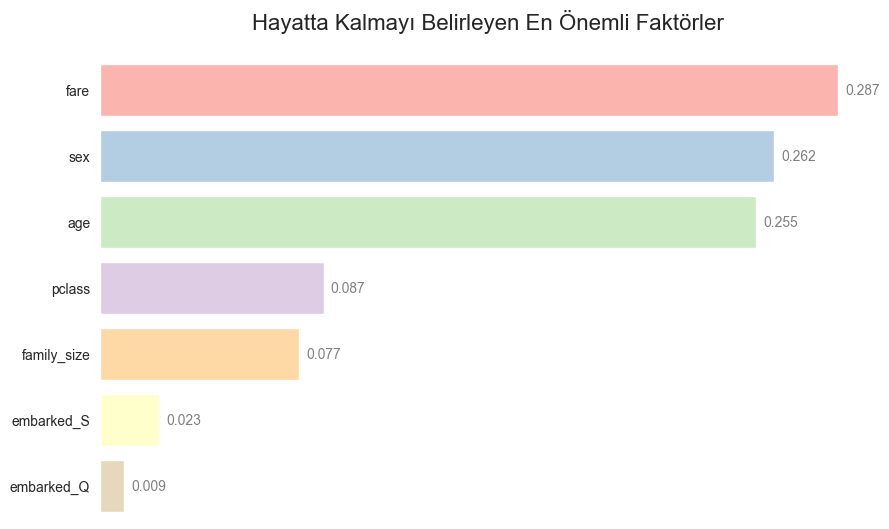


 9. ADIM: KİŞİSEL TAHMİN SONUCU
--- Tahmin İçin Girdi Olarak Kullanılan Veriniz ---
 pclass  sex  age  fare  embarked_Q  embarked_S  family_size
      1    0   21  80.0           0           1            1

--- Model Tahmini (Lojistik Regresyon) ---
Modelin Tahmini: HAYATTA KALIRDINIZ!
Model bu tahmininden %57.38 oranında emin.

--- Model Tahmini (Random Forest) ---
Modelin Tahmini: HAYATTA KALIRDINIZ!
Model bu tahmininden %57.38 oranında emin.

--- Proje Tamamlandı ---


In [ ]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print("Kütüphaneler başarıyla yüklendi.")

df = sns.load_dataset('titanic')

print("\n--- Veri Setinin İlk 5 Satırı ---")
print(df.head())
print("\n--- Veri Seti Bilgileri (Sütunlar ve Veri Tipleri) ---")
df.info()


print("\n--- Eksik Veri Analizi (Temizlemeden Önce) ---")
print(df.isnull().sum())

df['age'] = df['age'].fillna(df['age'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])
cols_to_drop = ['deck', 'embark_town']
existing_cols_to_drop = [col for col in cols_to_drop if col in df.columns]
df = df.drop(columns=existing_cols_to_drop)


print("\n--- Eksik Veri Analizi (Temizledikten Sonra) ---")
print(df.isnull().sum())


print("\n--- Veri Görselleştirme Başlıyor (Infographic Stili) ---")

sns.set_style("white")

pastel_palette = {0: "#E6B3B3", 1: "#74C6A9"}
genel_pastel = "Pastel1"


plt.figure(figsize=(8, 5))
palette_list_g1 = [pastel_palette[0], pastel_palette[1]]

ax = sns.countplot(
    x='survived',
    data=df,
    palette=palette_list_g1,
    saturation=1,
    order=[0, 1]
)
plt.title('Genel Hayatta Kalma Dağılımı', fontsize=16, pad=20)
plt.ylim(0)
sns.despine()
plt.xlabel("")
plt.ylabel("Yolcu Sayısı", fontsize=12)
plt.xticks([0, 1], ['Öldü', 'Hayatta Kaldı'], fontsize=12)
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=12, color='gray', padding=5)
plt.show()


plt.figure(figsize=(8, 5))
ax = sns.countplot(
    x='sex',
    hue='survived',
    data=df,
    palette=pastel_palette,
    saturation=1,
    order=['male', 'female']
)

plt.title('Cinsiyete Göre Hayatta Kalma (Pembe: Öldü, Yeşil: Yaşadı)', fontsize=16, pad=20)
plt.ylim(0)
sns.despine()
plt.xlabel("")
plt.ylabel("Yolcu Sayısı", fontsize=12)
plt.xticks([0, 1], ['Erkek', 'Kadın'], fontsize=12)
plt.legend([],[], frameon=False)
plt.show()


plt.figure(figsize=(10, 6))
ax = sns.countplot(
    x='pclass',
    hue='survived',
    data=df,
    palette=pastel_palette,
    saturation=1,
    order=sorted(df['pclass'].unique())
)

plt.title('Bilet Sınıfına Göre Hayatta Kalma (Pembe: Öldü, Yeşil: Yaşadı)', fontsize=16, pad=20)
plt.ylim(0)
sns.despine()
plt.xlabel("")
plt.ylabel("Yolcu Sayısı", fontsize=12)
plt.xticks([0, 1, 2], ['1. Sınıf', '2. Sınıf', '3. Sınıf'], fontsize=12)
plt.legend([],[], frameon=False)
plt.show()


plt.figure(figsize=(10, 6))
sns.kdeplot(
    data=df[df['survived'] == 1], x='age',
    color=pastel_palette[1], label='Hayatta Kaldı',
    fill=True, linewidth=0, alpha=0.7
)
sns.kdeplot(
    data=df[df['survived'] == 0], x='age',
    color=pastel_palette[0], label='Öldü',
    fill=True, linewidth=0, alpha=0.7
)
plt.title('Yaşa Göre Hayatta Kalma Yoğunluğu', fontsize=16, pad=20)
sns.despine(left=True, bottom=True)
plt.xlabel("Yaş", fontsize=12)
plt.ylabel("")
plt.yticks([])
plt.legend(frameon=False, loc='upper right', fontsize=12)
plt.show()



df['sex'] = df['sex'].map({'male': 0, 'female': 1})
df = pd.get_dummies(df, columns=['embarked'], drop_first=True)
df['family_size'] = df['sibsp'] + df['parch'] + 1

cols_to_drop = ['passengerId', 'name', 'ticket', 'sibsp', 'parch', 'who', 'adult_male', 'alive', 'class', 'alone']
existing_cols_to_drop = [col for col in cols_to_drop if col in df.columns]
df_model = df.drop(columns=existing_cols_to_drop)

print("\n--- Model İçin Hazırlanmış Veri Seti (İlk 5 Satır) ---")
print(df_model.head())



X = df_model.drop('survived', axis=1)
y = df_model['survived']
X_columns = X.columns
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nEğitim seti boyutu: {X_train.shape[0]} yolcu")
print(f"Test seti boyutu: {X_test.shape[0]} yolcu")

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)



model_lr = LogisticRegression(random_state=42)
model_lr.fit(X_train, y_train)
print("\n--- Lojistik Regresyon Modeli Başarıyla Eğitildi ---")


y_pred_lr = model_lr.predict(X_test)
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print(f"\n--- Model 1: Lojistik Regresyon Sonuçları ---")
print(f"Doğruluk (Accuracy) Skoru: {accuracy_lr:.4f} (Yani yaklaşık %{accuracy_lr*100:.2f})")
print("\nSınıflandırma Raporu:")
print(classification_report(y_test, y_pred_lr))


cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Greens', 
    linewidths=0,
    cbar=False,
    annot_kws={"size": 18}
)
plt.title('Karmaşıklık Matrisi: Modelin Karnesi', fontsize=16, pad=20)
plt.xlabel("Tahmin Edilen", fontsize=12)
plt.ylabel("Gerçek Durum", fontsize=12)
plt.xticks([0.5, 1.5], ['Tahmin: Öldü', 'Tahmin: Yaşadı'], fontsize=12)
plt.yticks([0.5, 1.5], ['Gerçek: Öldü', 'Gerçek: Yaşadı'], fontsize=12, rotation=0, va='center')
plt.show()



model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"\n--- Model 2: Random Forest Doğruluk Skoru ---")
print(f"Doğruluk (Accuracy) Skoru: {accuracy_rf:.4f} (Yani yaklaşık %{accuracy_rf*100:.2f})")

importances = pd.Series(model_rf.feature_importances_, index=X_columns).sort_values(ascending=False)

print("\n--- Modelın Kararını Etkileyen En Önemli Özellikler ---")
print(importances)

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x=importances.values,
    y=importances.index,
    palette=genel_pastel,
    saturation=1
)
plt.title('Hayatta Kalmayı Belirleyen En Önemli Faktörler', fontsize=16, pad=20)
sns.despine(left=True, bottom=True)
plt.xlabel("")
plt.ylabel("")
plt.xticks([])
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=10, color='gray', padding=5)
plt.show()



print("\n" + "="*50)
print(" 9. ADIM: KİŞİSEL TAHMİN SONUCU")
print("="*50)


pclass_tahmin = 1
sex_tahmin = 0 
age_tahmin = 21
fare_tahmin = 80.0
family_size_tahmin = 1 
biniş_limanı = 'S'


embarked_Q_tahmin = 1 if biniş_limanı == 'Q' else 0
embarked_S_tahmin = 1 if biniş_limanı == 'S' else 0

benim_yolcum_dict = {
    'pclass': pclass_tahmin,
    'sex': sex_tahmin,
    'age': age_tahmin,
    'fare': fare_tahmin,
    'family_size': family_size_tahmin,
    'embarked_Q': embarked_Q_tahmin,
    'embarked_S': embarked_S_tahmin
}

benim_yolcum_df = pd.DataFrame([benim_yolcum_dict], columns=X_columns)

print("--- Tahmin İçin Girdi Olarak Kullanılan Veriniz ---")
print(benim_yolcum_df.to_string(index=False))

benim_yolcum_scaled = scaler.transform(benim_yolcum_df)

tahminim_lr = model_lr.predict(benim_yolcum_scaled)
tahminim_yuzde_lr = model_lr.predict_proba(benim_yolcum_scaled)

print("\n--- Model Tahmini (Lojistik Regresyon) ---")
if tahminim_lr[0] == 1:
    sonuc_metni = "HAYATTA KALIRDINIZ!"
    yuzde = tahminim_yuzde_lr[0][1] * 100
else:
    sonuc_metni = "HAYATTA KALAMAZDINIZ."
    yuzde = tahminim_yuzde_lr[0][0] * 100

print(f"Modelin Tahmini: {sonuc_metni}")
print(f"Model bu tahmininden %{yuzde:.2f} oranında emin.")

tahminim_rf = model_lr.predict(benim_yolcum_scaled)
tahminim_yuzde_rf = model_lr.predict_proba(benim_yolcum_scaled)
print("\n--- Model Tahmini (Random Forest) ---")
if tahminim_rf[0] == 1:
    sonuc_metni_rf = "HAYATTA KALIRDINIZ!"
    yuzde_rf = tahminim_yuzde_rf[0][1] * 100
else:
    sonuc_metni_rf = "HAYATTA KALAMAZDINIZ."
    yuzde_rf = tahminim_yuzde_rf[0][0] * 100
print(f"Modelin Tahmini: {sonuc_metni_rf}")
print(f"Model bu tahmininden %{yuzde_rf:.2f} oranında emin.")

print("\n" + "="*50)
print("--- Proje Tamamlandı ---")